In [1]:
"""
Automated Water Quality Analysis and Anoxic Event Prediction
AQU-01: Anoxic Event Prediction | Pillar 3: Aquaculture & Hydrobiology
Author: Jesier S. Cresencio
Course: Computer Programming 1 | Final Project
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
import os

warnings.filterwarnings("ignore")

# ── CONFIGURATION ──────────────────────────────────────────────────────────────
DATA_PATH     = "filtered_dataset.csv"
OUTPUT_DIR    = "outputs"
ANOXIC_THRESH = 5.8        # mg/L
FEATURES      = ["TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
TARGET        = "anoxic"
RANDOM_STATE  = 42
TEST_SIZE     = 0.20

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Config loaded. Output dir ready.")

✅ Config loaded. Output dir ready.


In [2]:
# ── MODULE 1: DATA INGESTION ───────────────────────────────────────────────────
def ingest_data(path: str) -> pd.DataFrame:
    """Load CSV dataset with error handling and initial inspection."""
    try:
        df = pd.read_csv(path)
        print(f"[INGESTION] Loaded {len(df)} records | Columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found at: {path}")
    except Exception as e:
        raise RuntimeError(f"Data ingestion failed: {e}")

df_raw = ingest_data(DATA_PATH)
df_raw.head()

[INGESTION] Loaded 61 records | Columns: ['station', 'Date', 'Time', 'NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)', 'label_3class', 'Month']


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label_3class,Month
0,station1,2022-06-21,00:20:00,39.2026,8.2358,0.03690,26.6823,5.0622,22.8098,0.49767,0,6
1,station1,2022-06-09,09:00:00,21.3546,6.9357,0.04144,25.6674,6.0638,29.2653,0.92871,0,6
2,station1,2022-06-28,13:20:00,6.4908,6.6718,0.03952,28.6368,5.6639,37.0094,0.66451,0,6
3,station1,2022-06-07,23:20:00,32.0852,5.5421,0.02975,25.8758,5.5805,16.2770,0.49539,0,6
4,station1,2022-06-05,09:40:00,35.7478,8.7308,0.02615,26.6978,6.3227,16.2360,0.58028,0,6


In [3]:
# ── MODULE 1: DATA INGESTION ───────────────────────────────────────────────────
def ingest_data(path: str) -> pd.DataFrame:
    """Load CSV dataset with error handling and initial inspection."""
    try:
        df = pd.read_csv(path)
        print(f"[INGESTION] Loaded {len(df)} records | Columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found at: {path}")
    except Exception as e:
        raise RuntimeError(f"Data ingestion failed: {e}")

df_raw = ingest_data(DATA_PATH)
df_raw.head()

[INGESTION] Loaded 61 records | Columns: ['station', 'Date', 'Time', 'NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)', 'label_3class', 'Month']


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label_3class,Month
0,station1,2022-06-21,00:20:00,39.2026,8.2358,0.03690,26.6823,5.0622,22.8098,0.49767,0,6
1,station1,2022-06-09,09:00:00,21.3546,6.9357,0.04144,25.6674,6.0638,29.2653,0.92871,0,6
2,station1,2022-06-28,13:20:00,6.4908,6.6718,0.03952,28.6368,5.6639,37.0094,0.66451,0,6
3,station1,2022-06-07,23:20:00,32.0852,5.5421,0.02975,25.8758,5.5805,16.2770,0.49539,0,6
4,station1,2022-06-05,09:40:00,35.7478,8.7308,0.02615,26.6978,6.3227,16.2360,0.58028,0,6


In [4]:
# ── MODULE 2: DATA CLEANING & PREPROCESSING ───────────────────────────────────
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicates, handle missing values, enforce correct data types."""
    try:
        initial_len = len(df)
        df = df.drop_duplicates()
        print(f"[CLEANING] Removed {initial_len - len(df)} duplicate records.")

        numeric_cols = ["NITRATE(PPM)", "PH", "AMMONIA(mg/l)", "TEMP", "DO",
                        "TURBIDITY", "MANGANESE(mg/l)"]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        missing_before = df.isnull().sum().sum()
        df = df.dropna(subset=numeric_cols)
        print(f"[CLEANING] Dropped {missing_before} missing values. Records remaining: {len(df)}")

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)
        return df

    except Exception as e:
        raise RuntimeError(f"Data cleaning failed: {e}")

df_clean = clean_data(df_raw)
df_clean.head()

[CLEANING] Removed 0 duplicate records.
[CLEANING] Dropped 0 missing values. Records remaining: 61


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label_3class,Month
0,station1,2022-06-01,06:00:00,23.4097,8.7159,0.03183,28.5275,5.5905,32.2246,0.23006,0,6
1,station1,2022-06-01,01:00:00,13.6332,8.1351,0.02139,25.2448,5.8163,24.1941,0.38632,0,6
2,station1,2022-06-01,15:00:00,23.7179,7.8114,0.02662,25.1309,6.3879,18.5804,0.69637,0,6
3,station1,2022-06-01,19:40:00,5.0284,8.1385,0.02992,25.0107,5.3304,39.2070,0.96013,0,6
4,station1,2022-06-01,16:00:00,27.9388,5.8143,0.02243,29.3721,5.4064,18.1091,0.42398,0,6


In [5]:
# ── MODULE 3: FEATURE ENGINEERING & TARGET CREATION ───────────────────────────
def engineer_features(df: pd.DataFrame, threshold: float = ANOXIC_THRESH) -> pd.DataFrame:
    """Create binary anoxic label and validate features."""
    try:
        df[TARGET] = (df["DO"] < threshold).astype(int)
        df["day_of_month"] = df["Date"].dt.day
        print(f"[FEATURES] Anoxic threshold: DO < {threshold} mg/L")
        print(f"[FEATURES] Anoxic=1: {df[TARGET].sum()} | Normal=0: {(df[TARGET]==0).sum()}")
        return df
    except Exception as e:
        raise RuntimeError(f"Feature engineering failed: {e}")

df_feat = engineer_features(df_clean, threshold=ANOXIC_THRESH)
df_feat[[TARGET, "DO", "day_of_month"]].head(10)

[FEATURES] Anoxic threshold: DO < 5.8 mg/L
[FEATURES] Anoxic=1: 30 | Normal=0: 31


,anoxic,DO,day_of_month
0,1,5.5905,1
1,0,5.8163,1
2,0,6.3879,1
3,1,5.3304,1
4,1,5.4064,1
5,1,5.7786,2
6,1,5.6815,3
7,1,5.4439,3
8,1,5.5014,3
9,0,6.0326,3


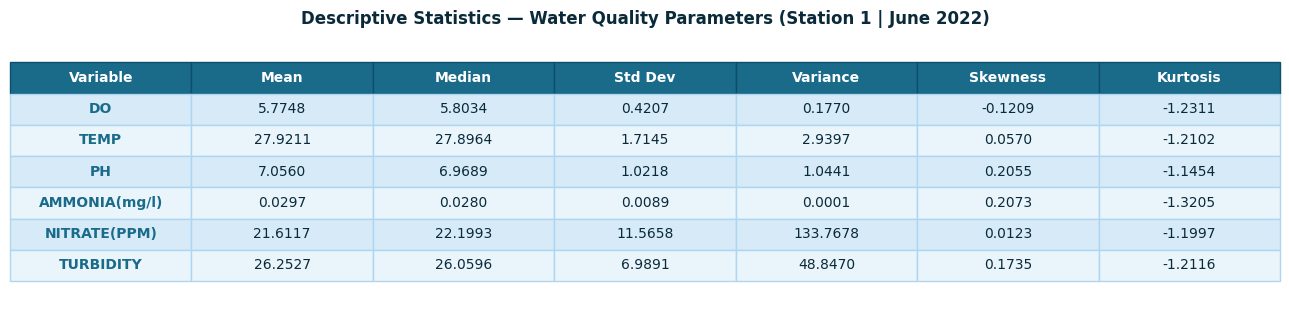

[TABLE] Saved fig_stats_table.png

[STATS] Pearson Correlation (DO vs TEMP): -0.1303


In [6]:
# ── MODULE 4: STATISTICAL ANALYSIS (NumPy-powered) ────────────────────────────
def statistical_analysis(df: pd.DataFrame) -> dict:
    """Compute descriptive statistics using NumPy and display as matplotlib table."""
    try:
        cols_of_interest = ["DO", "TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
        stats_dict = {}
        table_rows = []

        for col in cols_of_interest:
            arr        = df[col].dropna().to_numpy()
            mean_val   = np.mean(arr)
            median_val = np.median(arr)
            std_val    = np.std(arr, ddof=1)
            var_val    = np.var(arr, ddof=1)
            skew_val   = stats.skew(arr)
            kurt_val   = stats.kurtosis(arr)

            stats_dict[col] = {
                "mean": mean_val, "median": median_val,
                "std": std_val,   "var": var_val,
                "skew": skew_val, "kurtosis": kurt_val,
                "min": np.min(arr), "max": np.max(arr),
                "q1": np.percentile(arr, 25), "q3": np.percentile(arr, 75)
            }

            table_rows.append([
                col,
                f"{mean_val:.4f}",
                f"{median_val:.4f}",
                f"{std_val:.4f}",
                f"{var_val:.4f}",
                f"{skew_val:.4f}",
                f"{kurt_val:.4f}"
            ])

        # ── Matplotlib Table ───────────────────────────────────────────────────
        col_labels = ["Variable", "Mean", "Median", "Std Dev", "Variance", "Skewness", "Kurtosis"]
        row_colors_list = [
            ["#1a3a5c", "#1e4976", "#1e4976", "#1e4976", "#1e4976", "#1e4976", "#1e4976"],
            ["#0f2233", "#132b40", "#132b40", "#132b40", "#132b40", "#132b40", "#132b40"],
        ]

        fig, ax = plt.subplots(figsize=(13, 3.2))
        ax.axis("off")

        table = ax.table(
            cellText=table_rows,
            colLabels=col_labels,
            loc="center",
            cellLoc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.8)

        # Style header row
        for j in range(len(col_labels)):
            cell = table[0, j]
            cell.set_facecolor("#1a6b8a")
            cell.set_text_props(color="white", fontweight="bold")
            cell.set_edgecolor("#0d4f6b")

        # Style data rows with alternating colors
        for i in range(len(table_rows)):
            bg = "#d6eaf8" if i % 2 == 0 else "#eaf4fb"
            for j in range(len(col_labels)):
                cell = table[i + 1, j]
                cell.set_facecolor(bg)
                cell.set_edgecolor("#aed6f1")
                cell.set_text_props(color="#0a2a3a")
                # Highlight the Variable name column
                if j == 0:
                    cell.set_text_props(color="#1a6b8a", fontweight="bold")

        ax.set_title("Descriptive Statistics — Water Quality Parameters (Station 1 | June 2022)",
                     fontsize=12, fontweight="bold", color="#0a2a3a", pad=14)

        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/fig_stats_table.png", dpi=180, bbox_inches="tight")
        plt.show()
        print("[TABLE] Saved fig_stats_table.png")

        # Pearson correlation (DO vs TEMP)
        corr_cols   = ["DO", "TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
        corr_matrix = np.corrcoef(df[corr_cols].dropna().to_numpy().T)
        print(f"\n[STATS] Pearson Correlation (DO vs TEMP): {round(corr_matrix[0, 1], 4)}")

        return stats_dict

    except Exception as e:
        raise RuntimeError(f"Statistical analysis failed: {e}")

stats_results = statistical_analysis(df_feat)

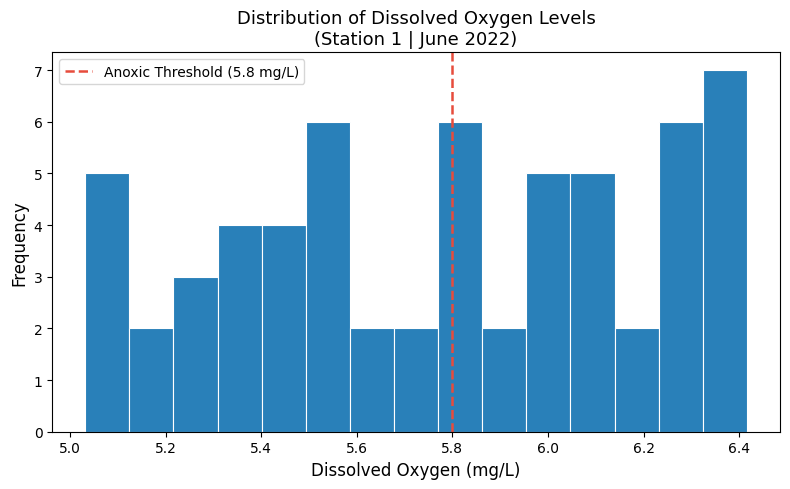

[PLOT] Saved fig1_do_histogram.png


In [7]:
# ── FIG 1: Histogram of Dissolved Oxygen ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_feat["DO"], bins=15, color="#2980b9", edgecolor="white", linewidth=0.8)
ax.axvline(ANOXIC_THRESH, color="#e74c3c", linestyle="--", linewidth=1.8,
           label=f"Anoxic Threshold ({ANOXIC_THRESH} mg/L)")
ax.set_xlabel("Dissolved Oxygen (mg/L)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Dissolved Oxygen Levels\n(Station 1 | June 2022)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_do_histogram.png", dpi=180)
plt.show()
print("[PLOT] Saved fig1_do_histogram.png")

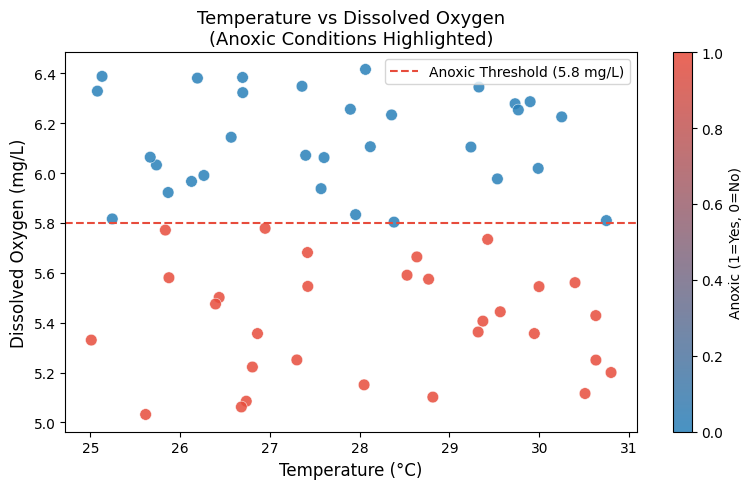

[PLOT] Saved fig2_scatter_temp_do.png


In [8]:
# ── FIG 2: Scatter — Temperature vs DO (anoxic color-coded) ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df_feat["TEMP"], df_feat["DO"], c=df_feat[TARGET],
                cmap=LinearSegmentedColormap.from_list("aq", ["#2980b9", "#e74c3c"]),
                edgecolors="white", linewidth=0.4, s=70, alpha=0.85)
ax.axhline(ANOXIC_THRESH, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Anoxic Threshold ({ANOXIC_THRESH} mg/L)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Anoxic (1=Yes, 0=No)")
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Dissolved Oxygen (mg/L)", fontsize=12)
ax.set_title("Temperature vs Dissolved Oxygen\n(Anoxic Conditions Highlighted)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_scatter_temp_do.png", dpi=180)
plt.show()
print("[PLOT] Saved fig2_scatter_temp_do.png")

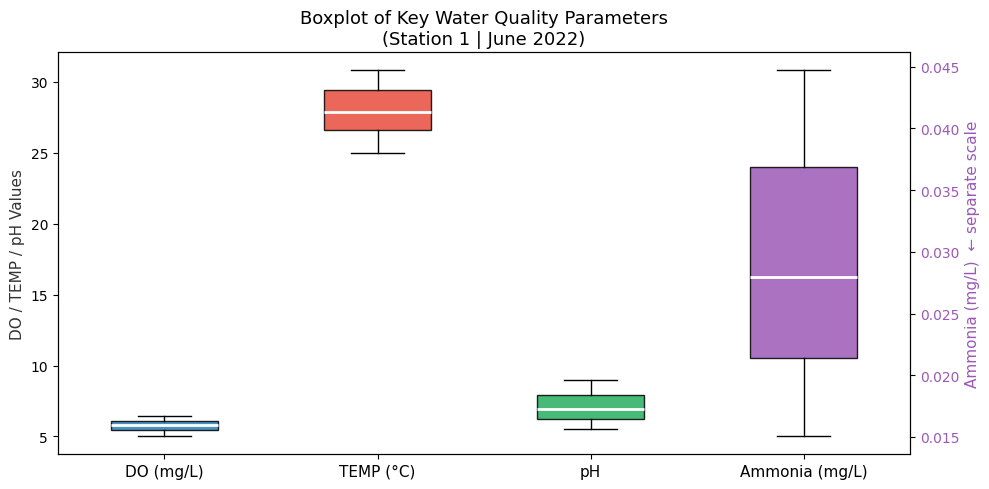

[PLOT] Saved fig3_boxplot_parameters.png


In [9]:
# ── FIG 3: Boxplot with Dual Y-Axis (Ammonia on separate scale) ───────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Plot DO, TEMP, pH on ax1
bp_main = ax1.boxplot(
    [df_feat["DO"].values, df_feat["TEMP"].values, df_feat["PH"].values],
    positions=[1, 2, 3], patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    widths=0.5
)
for patch, color in zip(bp_main["boxes"], ["#2980b9", "#e74c3c", "#27ae60"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Plot Ammonia on ax2
bp_amm = ax2.boxplot(
    [df_feat["AMMONIA(mg/l)"].values],
    positions=[4], patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    widths=0.5
)
bp_amm["boxes"][0].set_facecolor("#9b59b6")
bp_amm["boxes"][0].set_alpha(0.85)

ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(["DO (mg/L)", "TEMP (°C)", "pH", "Ammonia (mg/L)"], fontsize=11)
ax1.set_ylabel("DO / TEMP / pH Values", fontsize=11, color="#333")
ax2.set_ylabel("Ammonia (mg/L)  ← separate scale", fontsize=11, color="#9b59b6")
ax2.tick_params(axis='y', labelcolor="#9b59b6")
ax1.set_title("Boxplot of Key Water Quality Parameters\n(Station 1 | June 2022)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_boxplot_parameters.png", dpi=180)
plt.show()
print("[PLOT] Saved fig3_boxplot_parameters.png")

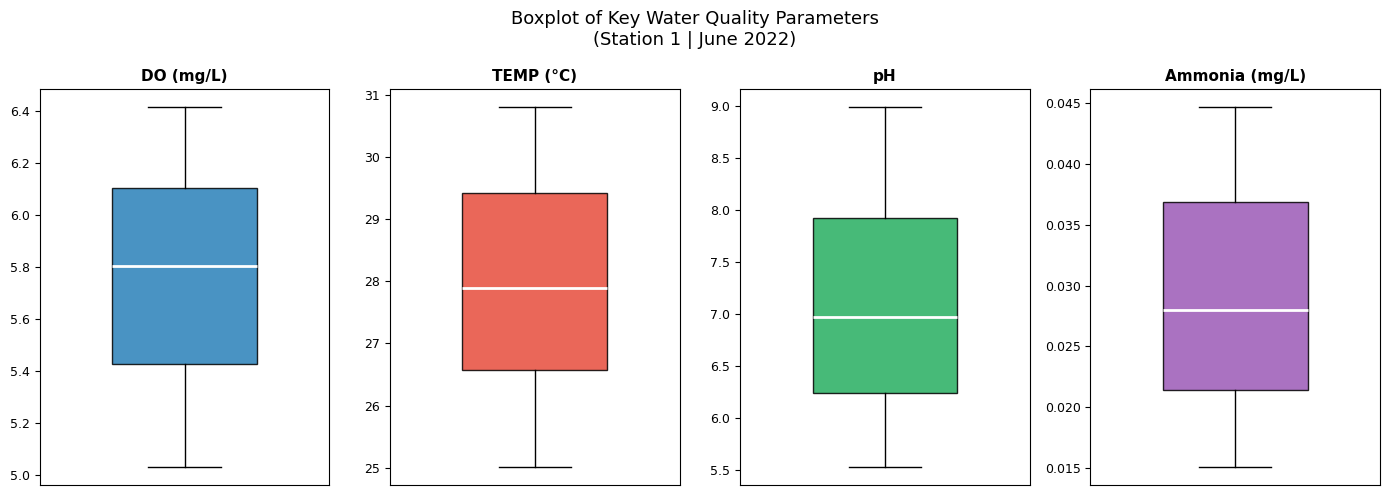

[PLOT] Saved fig3_boxplot_parameters.png


In [10]:
# ── FIG 3: Boxplot as 2x2 Subplots (each on its own scale) ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
params = ["DO", "TEMP", "PH", "AMMONIA(mg/l)"]
labels = ["DO (mg/L)", "TEMP (°C)", "pH", "Ammonia (mg/L)"]
colors = ["#2980b9", "#e74c3c", "#27ae60", "#9b59b6"]

for ax, col, label, color in zip(axes, params, labels, colors):
    bp = ax.boxplot(df_feat[col].values, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2), widths=0.5)
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.85)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle("Boxplot of Key Water Quality Parameters\n(Station 1 | June 2022)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_boxplot_parameters.png", dpi=180)
plt.show()
print("[PLOT] Saved fig3_boxplot_parameters.png")

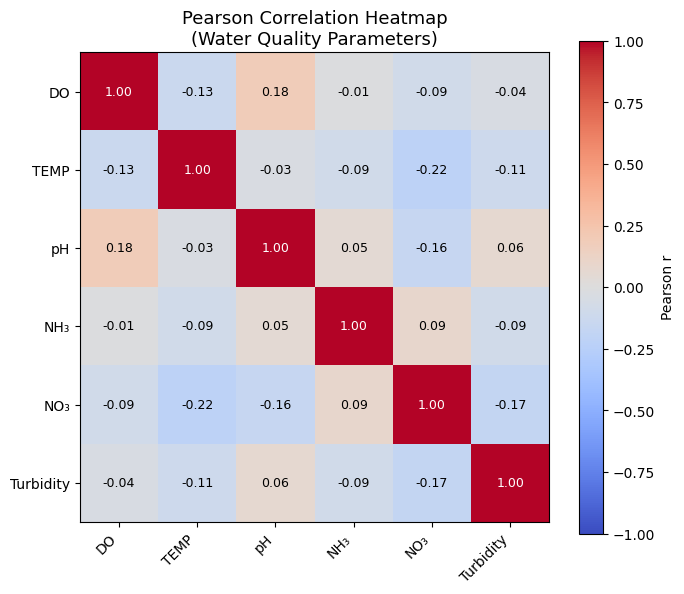

[PLOT] Saved fig4_correlation_heatmap.png


In [11]:
# ── FIG 4: Correlation Heatmap ────────────────────────────────────────────────
cols = ["DO", "TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
corr = df_feat[cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(["DO", "TEMP", "pH", "NH₃", "NO₃", "Turbidity"], rotation=45, ha="right")
ax.set_yticklabels(["DO", "TEMP", "pH", "NH₃", "NO₃", "Turbidity"])
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(corr.values[i,j]) > 0.5 else "black")
ax.set_title("Pearson Correlation Heatmap\n(Water Quality Parameters)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_correlation_heatmap.png", dpi=180)
plt.show()
print("[PLOT] Saved fig4_correlation_heatmap.png")

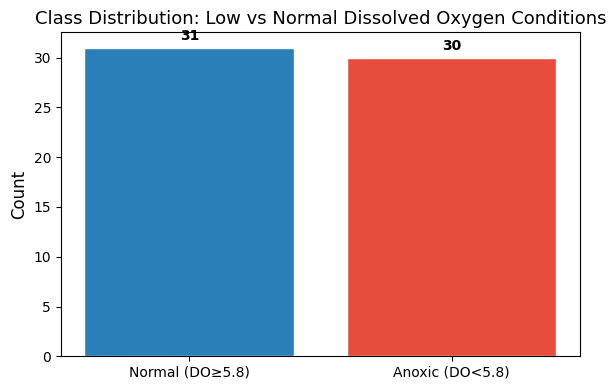

[PLOT] Saved fig5_class_distribution.png


In [12]:
# ── FIG 5: Anoxic vs Normal Class Count ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_feat[TARGET].value_counts().sort_index()
bars = ax.bar(["Normal (DO≥5.8)", "Anoxic (DO<5.8)"],
               counts.values,
               color=["#2980b9", "#e74c3c"], edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontweight="bold")
ax.set_title("Class Distribution: Low vs Normal Dissolved Oxygen Conditions", fontsize=13)
ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_class_distribution.png", dpi=180)
plt.show()
print("[PLOT] Saved fig5_class_distribution.png")

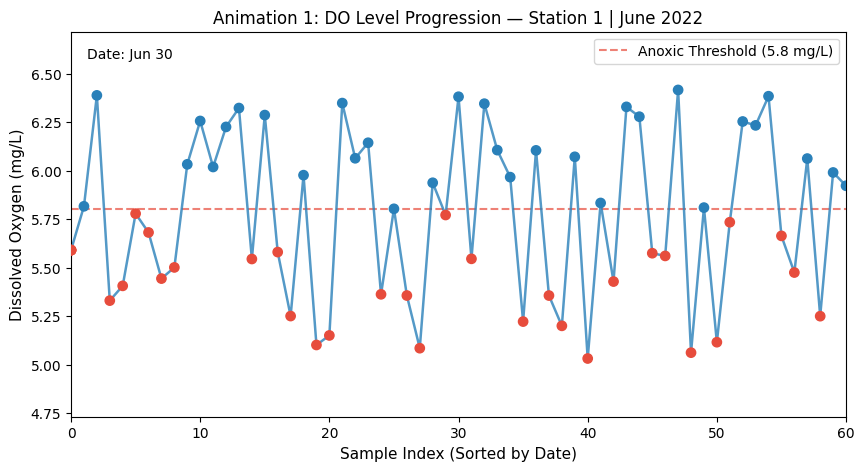

[ANIM] Saved anim1_do_over_time.gif


In [13]:
# ── MODULE 6: ANIMATION 1 — DO Levels Over Time ───────────────────────────────
def animate_do_over_time(df: pd.DataFrame):
    """Animated line chart showing DO evolution across June 2022."""
    try:
        df_sorted = df.sort_values("Date").reset_index(drop=True)
        x_vals = np.arange(len(df_sorted))
        y_vals = df_sorted["DO"].values

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_xlim(0, len(x_vals) - 1)
        ax.set_ylim(y_vals.min() - 0.3, y_vals.max() + 0.3)
        ax.axhline(ANOXIC_THRESH, color="#e74c3c", linestyle="--", linewidth=1.5,
                   label=f"Anoxic Threshold ({ANOXIC_THRESH} mg/L)", alpha=0.7)
        ax.set_xlabel("Sample Index (Sorted by Date)", fontsize=11)
        ax.set_ylabel("Dissolved Oxygen (mg/L)", fontsize=11)
        ax.set_title("Animation 1: DO Level Progression — Station 1 | June 2022", fontsize=12)
        ax.legend(loc="upper right")

        line, = ax.plot([], [], color="#2980b9", linewidth=1.8, alpha=0.8)
        scat  = ax.scatter([], [], c=[], cmap=LinearSegmentedColormap.from_list(
            "aq", ["#2980b9","#e74c3c"]), s=45, zorder=5, vmin=0, vmax=1)
        timestamp = ax.text(0.02, 0.93, "", transform=ax.transAxes, fontsize=10)

        xs_hist, ys_hist, cs_hist = [], [], []

        def update(frame):
            xs_hist.append(x_vals[frame])
            ys_hist.append(y_vals[frame])
            cs_hist.append(df_sorted[TARGET].iloc[frame])
            line.set_data(xs_hist, ys_hist)
            scat.set_offsets(np.column_stack([xs_hist, ys_hist]))
            scat.set_array(np.array(cs_hist))
            timestamp.set_text(f"Date: {df_sorted['Date'].iloc[frame].strftime('%b %d')}")
            return line, scat, timestamp

        ani = animation.FuncAnimation(fig, update, frames=len(x_vals),
                                      interval=120, blit=True, repeat=False)
        ani.save(f"{OUTPUT_DIR}/anim1_do_over_time.gif", writer="pillow", fps=8, dpi=120)
        plt.show()
        plt.close()
        print("[ANIM] Saved anim1_do_over_time.gif")

    except Exception as e:
        raise RuntimeError(f"Animation 1 failed: {e}")

animate_do_over_time(df_feat)

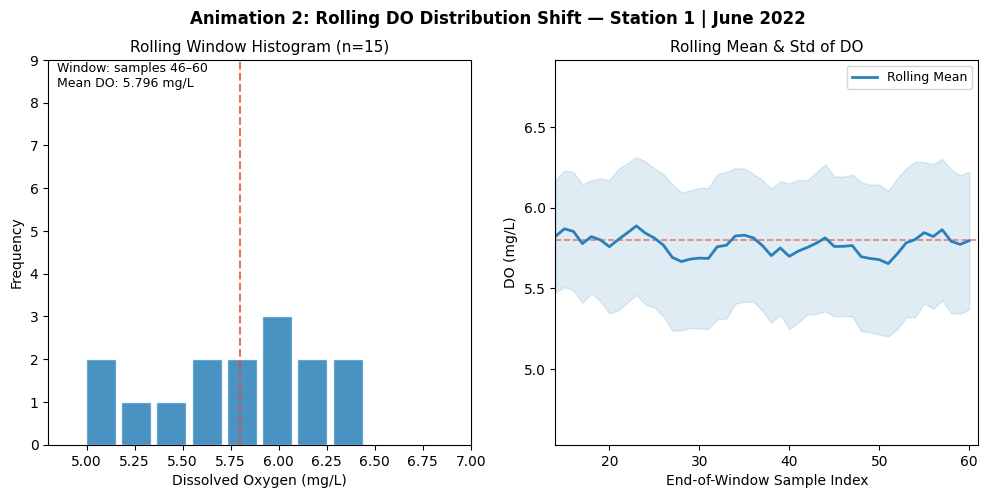

[ANIM] Saved anim2_rolling_distribution.gif


In [14]:
# ── MODULE 7: ANIMATION 2 — Rolling Distribution Shift ───────────────────────
def animate_rolling_distribution(df: pd.DataFrame):
    """Rolling window histogram of DO showing distribution shift over time."""
    try:
        df_sorted = df.sort_values("Date").reset_index(drop=True)
        do_vals   = df_sorted["DO"].values
        WINDOW    = 15
        n_frames  = len(do_vals) - WINDOW + 1

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle("Animation 2: Rolling DO Distribution Shift — Station 1 | June 2022",
                     fontsize=12, fontweight="bold")

        ax1.set_title("Rolling Window Histogram (n=15)", fontsize=11)
        ax1.set_xlabel("Dissolved Oxygen (mg/L)"); ax1.set_ylabel("Frequency")
        ax1.set_xlim(4.8, 7.0); ax1.set_ylim(0, 9)
        ax1.axvline(ANOXIC_THRESH, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.8)

        ax2.set_title("Rolling Mean & Std of DO", fontsize=11)
        ax2.set_xlabel("End-of-Window Sample Index"); ax2.set_ylabel("DO (mg/L)")
        ax2.set_xlim(WINDOW-1, len(do_vals))
        ax2.set_ylim(do_vals.min() - 0.5, do_vals.max() + 0.5)
        ax2.axhline(ANOXIC_THRESH, color="#e74c3c", linestyle="--", linewidth=1.2, alpha=0.7)

        mean_line, = ax2.plot([], [], color="#2980b9", linewidth=2, label="Rolling Mean")
        ax2.legend(fontsize=9)

        mean_xs, mean_ys, std_ys = [], [], []
        bin_edges   = np.linspace(4.8, 7.0, 13)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Init bars
        init_counts, _ = np.histogram(do_vals[:WINDOW], bins=bin_edges)
        ax1.bar(bin_centers, init_counts, width=(bin_edges[1]-bin_edges[0])*0.85,
                color="#2980b9", edgecolor="white", alpha=0.85)
        window_txt = ax1.text(0.02, 0.93, "", transform=ax1.transAxes, fontsize=9)

        def update(frame):
            window_data = do_vals[frame: frame + WINDOW]
            counts, _   = np.histogram(window_data, bins=bin_edges)
            for rect, h in zip(ax1.patches, counts):
                rect.set_height(h)
            window_txt.set_text(
                f"Window: samples {frame}–{frame+WINDOW-1}\n"
                f"Mean DO: {np.mean(window_data):.3f} mg/L")
            end_idx = frame + WINDOW - 1
            mean_xs.append(end_idx)
            mean_ys.append(np.mean(window_data))
            std_ys.append(np.std(window_data))
            mean_line.set_data(mean_xs, mean_ys)
            for coll in ax2.collections:
                coll.remove()
            ax2.fill_between(mean_xs,
                              np.array(mean_ys) - np.array(std_ys),
                              np.array(mean_ys) + np.array(std_ys),
                              color="#2980b9", alpha=0.15)
            return ()

        ani = animation.FuncAnimation(fig, update, frames=n_frames,
                                      interval=200, blit=False, repeat=False)
        ani.save(f"{OUTPUT_DIR}/anim2_rolling_distribution.gif", writer="pillow", fps=5, dpi=120)
        plt.show()
        plt.close()
        print("[ANIM] Saved anim2_rolling_distribution.gif")

    except Exception as e:
        raise RuntimeError(f"Animation 2 failed: {e}")

animate_rolling_distribution(df_feat)

[ML] Test Accuracy:    0.3077
[ML] 5-Fold CV:        0.5231 ± 0.1151
[ML] Confusion Matrix:
[[2 5]
 [4 2]]

[ML] Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.33      0.29      0.31         7
  Anoxic (1)       0.29      0.33      0.31         6

    accuracy                           0.31        13
   macro avg       0.31      0.31      0.31        13
weighted avg       0.31      0.31      0.31        13



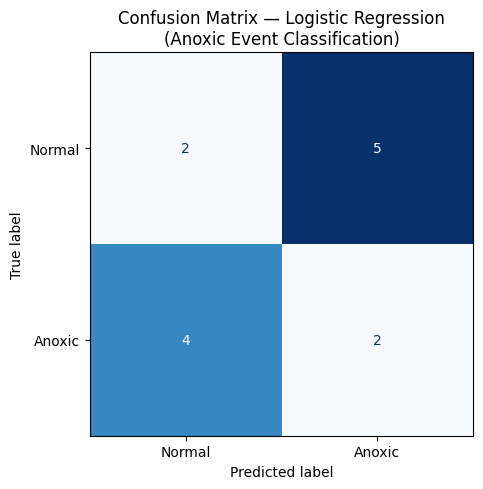

[PLOT] Saved fig6_confusion_matrix.png


In [15]:
# ── MODULE 8: MACHINE LEARNING — Logistic Regression ─────────────────────────
X = df_feat[FEATURES].to_numpy()
y = df_feat[TARGET].to_numpy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc      = accuracy_score(y_test, y_pred)
cm       = confusion_matrix(y_test, y_pred)
cv_scores = cross_val_score(model, X_scaled, y, cv=5)

print(f"[ML] Test Accuracy:    {acc:.4f}")
print(f"[ML] 5-Fold CV:        {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("[ML] Confusion Matrix:")
print(cm)
print("\n[ML] Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Anoxic (1)"]))

# ── FIG 6: Confusion Matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anoxic"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Logistic Regression\n(Anoxic Event Classification)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_confusion_matrix.png", dpi=180)
plt.show()
print("[PLOT] Saved fig6_confusion_matrix.png")

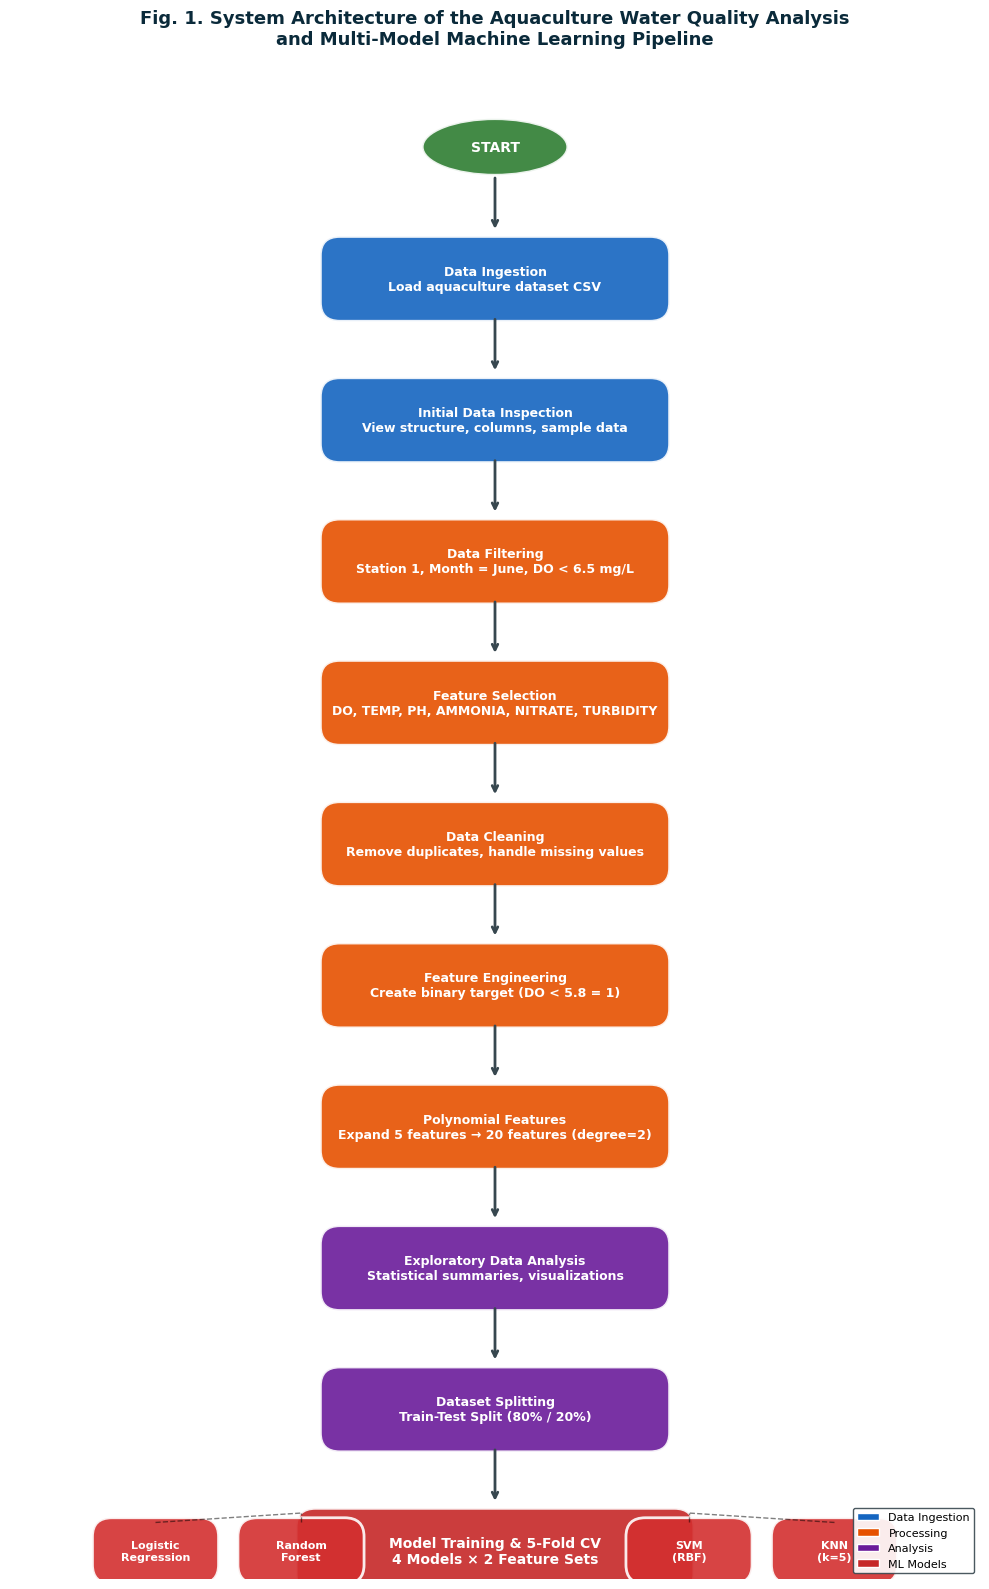

In [16]:
# flowchart_generator_vscode.py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

def create_system_flowchart():
    fig, ax = plt.subplots(figsize=(10, 16))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 16)
    ax.axis('off')
    
    colors = {
        'start_end': '#2E7D32',
        'ingestion': '#1565C0',
        'processing': '#E65100',
        'analysis': '#6A1B9A',
        'ml': '#C62828',
        'text': 'white',
        'arrow': '#37474F'
    }
    
    def draw_box(ax, x, y, width, height, color, text, fontsize=9):
        box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                             boxstyle="round,pad=0.05,rounding_size=0.2",
                             facecolor=color, edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(box)
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
                color=colors['text'], fontweight='bold', wrap=True)
    
    def draw_oval(ax, x, y, width, height, color, text, fontsize=10):
        oval = mpatches.Ellipse((x, y), width, height, facecolor=color,
                                edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(oval)
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
                color=colors['text'], fontweight='bold')
    
    def draw_arrow(ax, x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=colors['arrow'], lw=2))
    
    # Draw nodes (from top to bottom)
    draw_oval(ax, 5, 15.2, 1.5, 0.6, colors['start_end'], 'START')
    draw_arrow(ax, 5, 14.9, 5, 14.3)
    
    draw_box(ax, 5, 13.8, 3.5, 0.8, colors['ingestion'],
             'Data Ingestion\nLoad aquaculture dataset CSV')
    draw_arrow(ax, 5, 13.4, 5, 12.8)
    
    draw_box(ax, 5, 12.3, 3.5, 0.8, colors['ingestion'],
             'Initial Data Inspection\nView structure, columns, sample data')
    draw_arrow(ax, 5, 11.9, 5, 11.3)
    
    draw_box(ax, 5, 10.8, 3.5, 0.8, colors['processing'],
             'Data Filtering\nStation 1, Month = June, DO < 6.5 mg/L')
    draw_arrow(ax, 5, 10.4, 5, 9.8)
    
    draw_box(ax, 5, 9.3, 3.5, 0.8, colors['processing'],
             'Feature Selection\nDO, TEMP, PH, AMMONIA, NITRATE, TURBIDITY')
    draw_arrow(ax, 5, 8.9, 5, 8.3)
    
    draw_box(ax, 5, 7.8, 3.5, 0.8, colors['processing'],
             'Data Cleaning\nRemove duplicates, handle missing values')
    draw_arrow(ax, 5, 7.4, 5, 6.8)
    
    draw_box(ax, 5, 6.3, 3.5, 0.8, colors['processing'],
             'Feature Engineering\nCreate binary target (DO < 5.8 = 1)')
    draw_arrow(ax, 5, 5.9, 5, 5.3)
    
    draw_box(ax, 5, 4.8, 3.5, 0.8, colors['processing'],
             'Polynomial Features\nExpand 5 features → 20 features (degree=2)')
    draw_arrow(ax, 5, 4.4, 5, 3.8)
    
    draw_box(ax, 5, 3.3, 3.5, 0.8, colors['analysis'],
             'Exploratory Data Analysis\nStatistical summaries, visualizations')
    draw_arrow(ax, 5, 2.9, 5, 2.3)
    
    draw_box(ax, 5, 1.8, 3.5, 0.8, colors['analysis'],
             'Dataset Splitting\nTrain-Test Split (80% / 20%)')
    draw_arrow(ax, 5, 1.4, 5, 0.8)
    
    # Main ML box
    draw_box(ax, 5, 0.3, 4.0, 0.8, colors['ml'],
             'Model Training & 5-Fold CV\n4 Models × 2 Feature Sets', fontsize=10)
    
    # Side model boxes
    model_boxes = [(1.5, 'Logistic\nRegression'), (3.0, 'Random\nForest'),
                   (7.0, 'SVM\n(RBF)'), (8.5, 'KNN\n(k=5)')]
    for mx, mtext in model_boxes:
        draw_box(ax, mx, 0.3, 1.2, 0.6, '#D32F2F', mtext, fontsize=8)
        ax.plot([mx, 3.0 if mx < 5 else 7.0], [0.6, 0.7], 'k--', alpha=0.5, lw=1)
    
    # Title
    ax.set_title('Fig. 1. System Architecture of the Aquaculture Water Quality Analysis\n'
                 'and Multi-Model Machine Learning Pipeline',
                 fontsize=13, fontweight='bold', pad=20, color='#0a2a3a')
    
    # Legend
    legend_elements = [
        mpatches.Patch(facecolor=colors['ingestion'], edgecolor='white', label='Data Ingestion'),
        mpatches.Patch(facecolor=colors['processing'], edgecolor='white', label='Processing'),
        mpatches.Patch(facecolor=colors['analysis'], edgecolor='white', label='Analysis'),
        mpatches.Patch(facecolor=colors['ml'], edgecolor='white', label='ML Models'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
             framealpha=0.9, edgecolor='#37474F')
    
    plt.tight_layout()
    plt.savefig('system_architecture_flowchart.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

if __name__ == "__main__":
    create_system_flowchart()

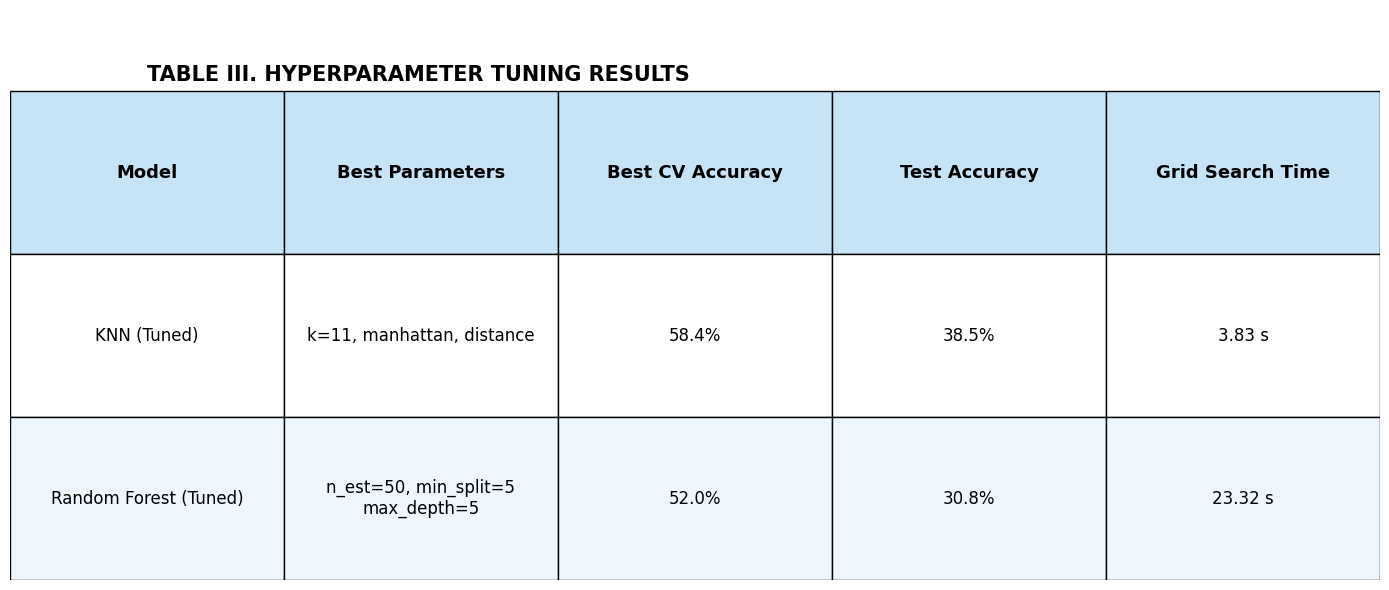

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Table data
columns = ["Model", "Best Parameters", "Best CV Accuracy", "Test Accuracy", "Grid Search Time"]
rows = [
    ["KNN (Tuned)", "k=11, manhattan, distance", "58.4%", "38.5%", "3.83 s"],
    # Put max_depth on a new line using '\n'
    ["Random Forest (Tuned)", "n_est=50, min_split=5\nmax_depth=5", "52.0%", "30.8%", "23.32 s"],
]

# Colors
header_color = "#c7e3f6"
row_colors = ["#ffffff", "#eef7ff"]

# Draw header
for i, col in enumerate(columns):
    ax.text(i, 2, col, ha="center", va="center", fontsize=13, weight="bold")
    ax.add_patch(patches.Rectangle((i-0.5, 1.5), 1, 1, fill=True, color=header_color, ec='black', lw=1))

# Draw rows
for r, row in enumerate(rows):
    for c, value in enumerate(row):
        ax.text(c, 1-r, value, ha="center", va="center", fontsize=12, wrap=True)
        ax.add_patch(
            patches.Rectangle(
                (c-0.5, 0.5 - r), 
                1, 1,
                fill=True,
                color=row_colors[r % 2],
                ec='black',
                lw=1
            )
        )

# Title
plt.text(0, 2.6, "TABLE III. HYPERPARAMETER TUNING RESULTS",
         ha="left", va="center", fontsize=15, weight="bold")

plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 3)

plt.tight_layout()
plt.show()
